<a href="https://colab.research.google.com/github/prathampharmaai/Pratham-/blob/main/QSAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install rdkit
!pip install lazypredict
import lazypredict
from lazypredict.Supervised import LazyRegressor
from rdkit.Chem import Descriptors, Crippen, AllChem as Chem
from rdkit import DataStructs
import pandas as pd

url = 'https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv'
df = pd.read_csv(url)

df.head(5)
print(df.isnull().sum())

MolLogP               0
MolWt                 0
NumRotatableBonds     0
AromaticProportion    0
logS                  0
dtype: int64


In [ ]:
from google.colab import files

# Download the solubility distribution plot
files.download('solubility_dist.png')

# Download the solubility prediction plot
files.download('solubility_predict.png')

In [11]:
df.describe()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
count,1144.000000,1144.000000,1144.000000,1144.000000,1144.000000
mean,2.449133,204.631675,2.173951,0.364932,-3.057997
std,1.866003,102.620500,2.627398,0.343305,2.096502
min,-7.571400,16.043000,0.000000,0.000000,-11.600000
25%,1.414900,122.126000,0.000000,0.000000,-4.332250
50%,2.340300,183.594500,1.000000,0.375000,-2.870500
75%,3.406475,270.715750,3.000000,0.666667,-1.600000
max,10.388600,780.949000,23.000000,1.000000,1.580000


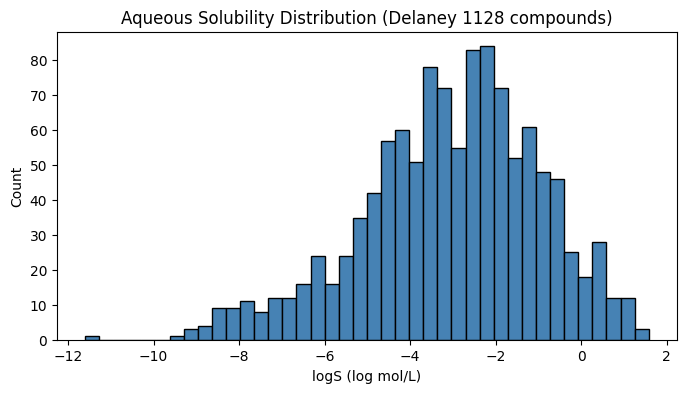

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df['logS'], bins=40, color='steelblue', edgecolor='black')
plt.xlabel('logS (log mol/L)')
plt.ylabel('Count')
plt.title('Aqueous Solubility Distribution (Delaney 1128 compounds)')
plt.savefig('solubility_dist.png')
plt.show()

In [13]:
import pandas as pd
url = 'https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv'
df = pd.read_csv(url)

from sklearn.model_selection import train_test_split

X = df[['MolLogP','MolWt','NumRotatableBonds','AromaticProportion']]
y = df['logS']

x_train, x_test, y_train, y_test = train_test_split (X, y, test_size = 0.2,random_state=42)

print('Train size:', len(x_train))
print('Test size:', len(x_test))


from sklearn.ensemble import RandomForestRegressor
import numpy as np
np.random.seed(42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
r2 = model.score(x_test, y_test)
print('R2 score:', r2)

y_pred = model.predict(x_test)



Train size: 915
Test size: 229
R2 score: 0.889824807388066


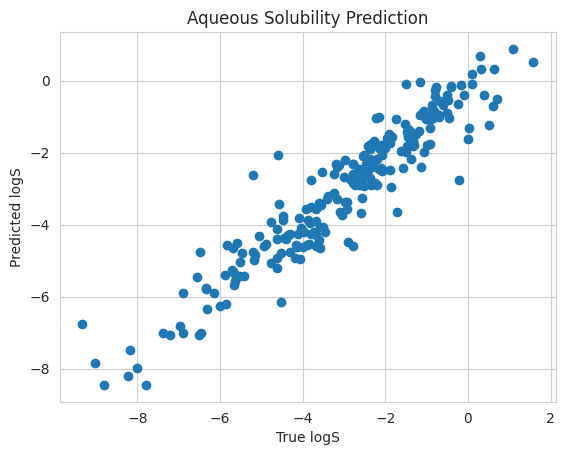

In [14]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.scatter(y_test, y_pred)
plt.xlabel('True logS')
plt.ylabel('Predicted logS')
plt.title('Aqueous Solubility Prediction')
plt.savefig('solubility_predict.png')
plt.show()

Aqueous Solubility Distribution (Histogram):


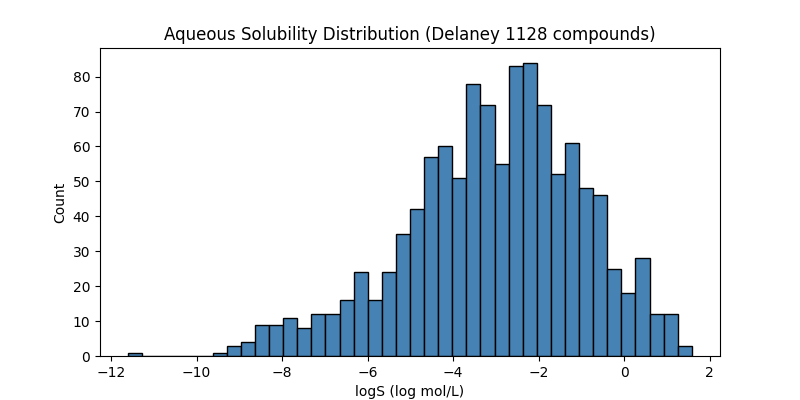


Aqueous Solubility Prediction (Scatter Plot):


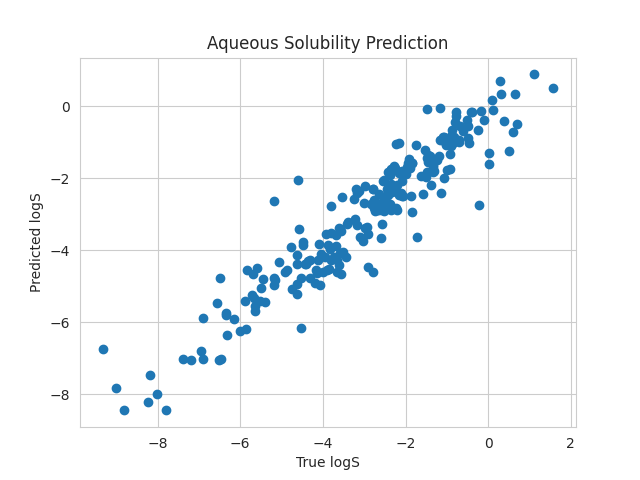

In [15]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

print("Aqueous Solubility Distribution (Histogram):")
display(Image('solubility_dist.png'))

print("\nAqueous Solubility Prediction (Scatter Plot):")
display(Image('solubility_predict.png'))

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = 'https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv'
df = pd.read_csv(url)

X = df[['MolLogP','MolWt','NumRotatableBonds','AromaticProportion']]
y = df['logS']

x_train, x_test, y_train, y_test = train_test_split (X, y, test_size = 0.2,random_state=42)



dif= LazyRegressor(verbose=0,ignore_warnings=True,custom_metric=None)
models,predictions=dif.fit(x_train,x_test,y_train,y_test)


In [19]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.889790,0.891723,0.686655,0.409383
RandomForestRegressor,0.887730,0.889700,0.693041,0.459461
BaggingRegressor,0.881975,0.884046,0.710583,0.093329
HistGradientBoostingRegressor,0.878605,0.880735,0.720656,0.362431
LGBMRegressor,0.872453,0.874691,0.738691,0.064775
XGBRegressor,0.871402,0.873659,0.741727,0.168812
GradientBoostingRegressor,0.868565,0.870871,0.749866,0.333618
KNeighborsRegressor,0.854604,0.857155,0.788686,0.023944
SVR,0.853920,0.856483,0.790539,0.064362


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

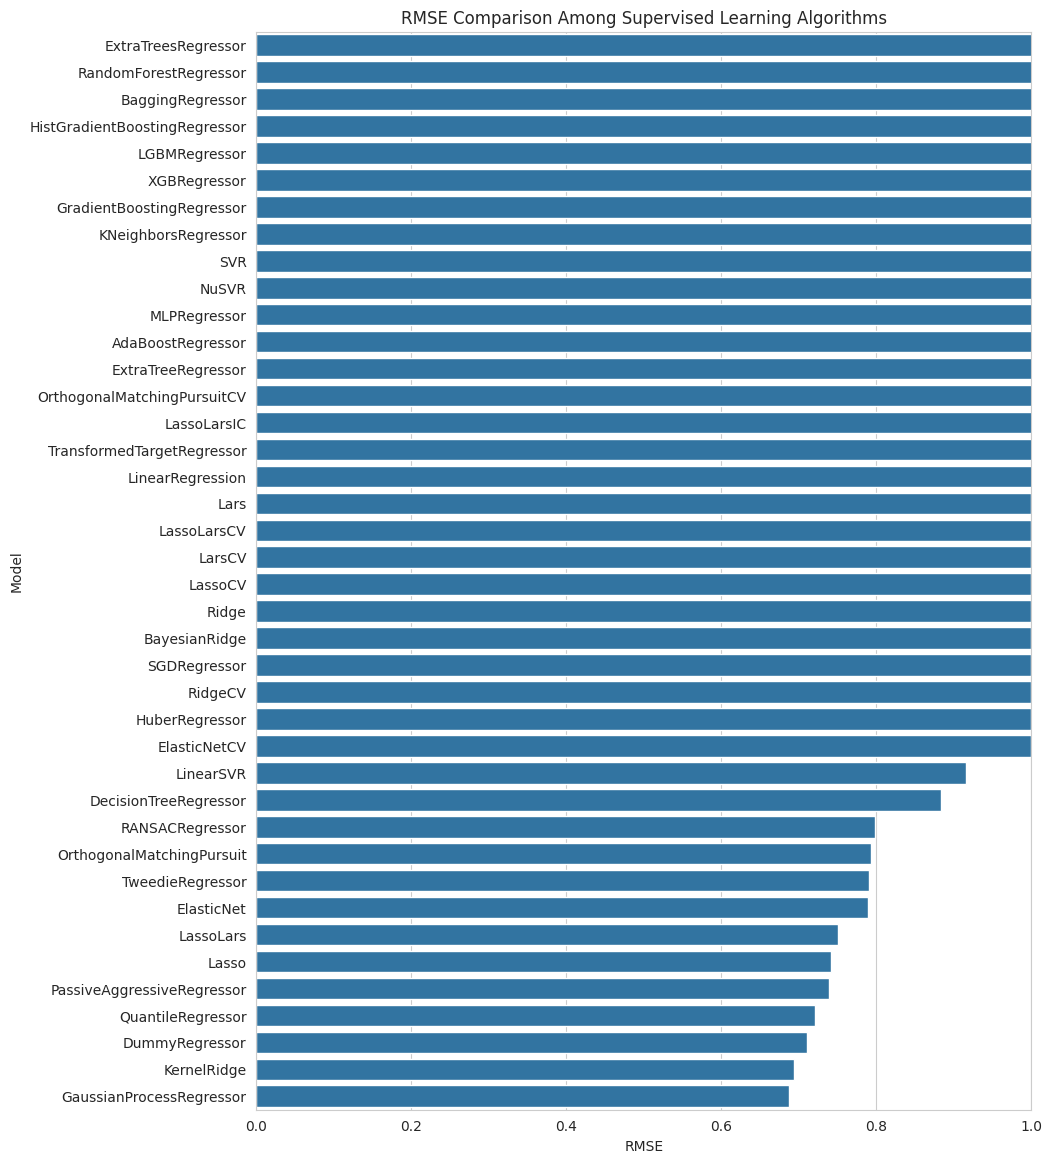

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(10,14))
ax = sns.barplot(y=models.index, x="RMSE", data=models.sort_values("RMSE", ascending=False))
ax.set(xlim=(0,1))
ax.set_xlabel('RMSE')
ax.set_title('RMSE Comparison Among Supervised Learning Algorithms')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

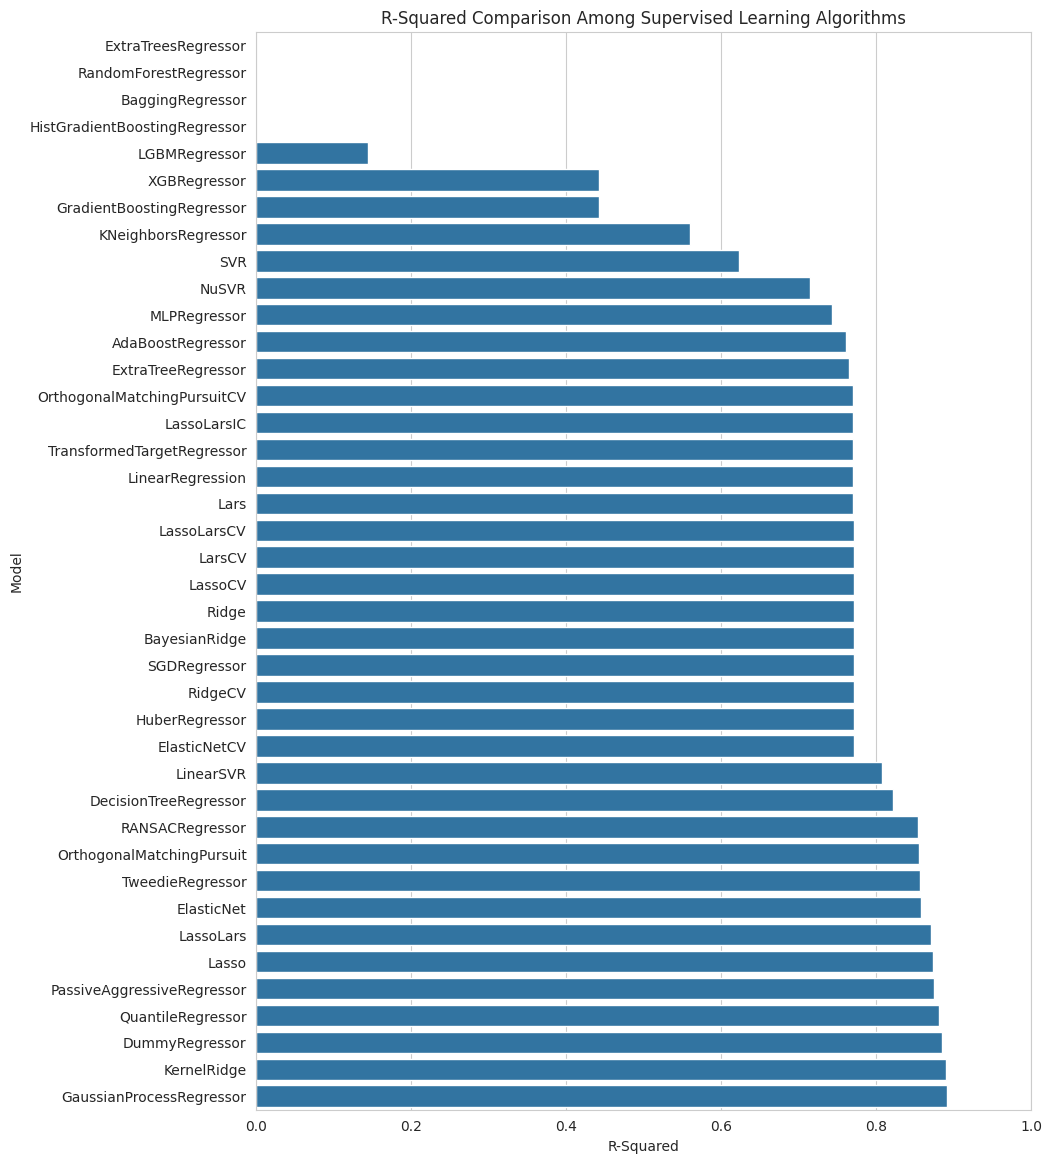

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(10,14))
ax = sns.barplot(y=models.index, x="R-Squared", data=models.sort_values("RMSE", ascending=False))
ax.set(xlim=(0,1))
ax.set_xlabel('R-Squared')
ax.set_title('R-Squared Comparison Among Supervised Learning Algorithms')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

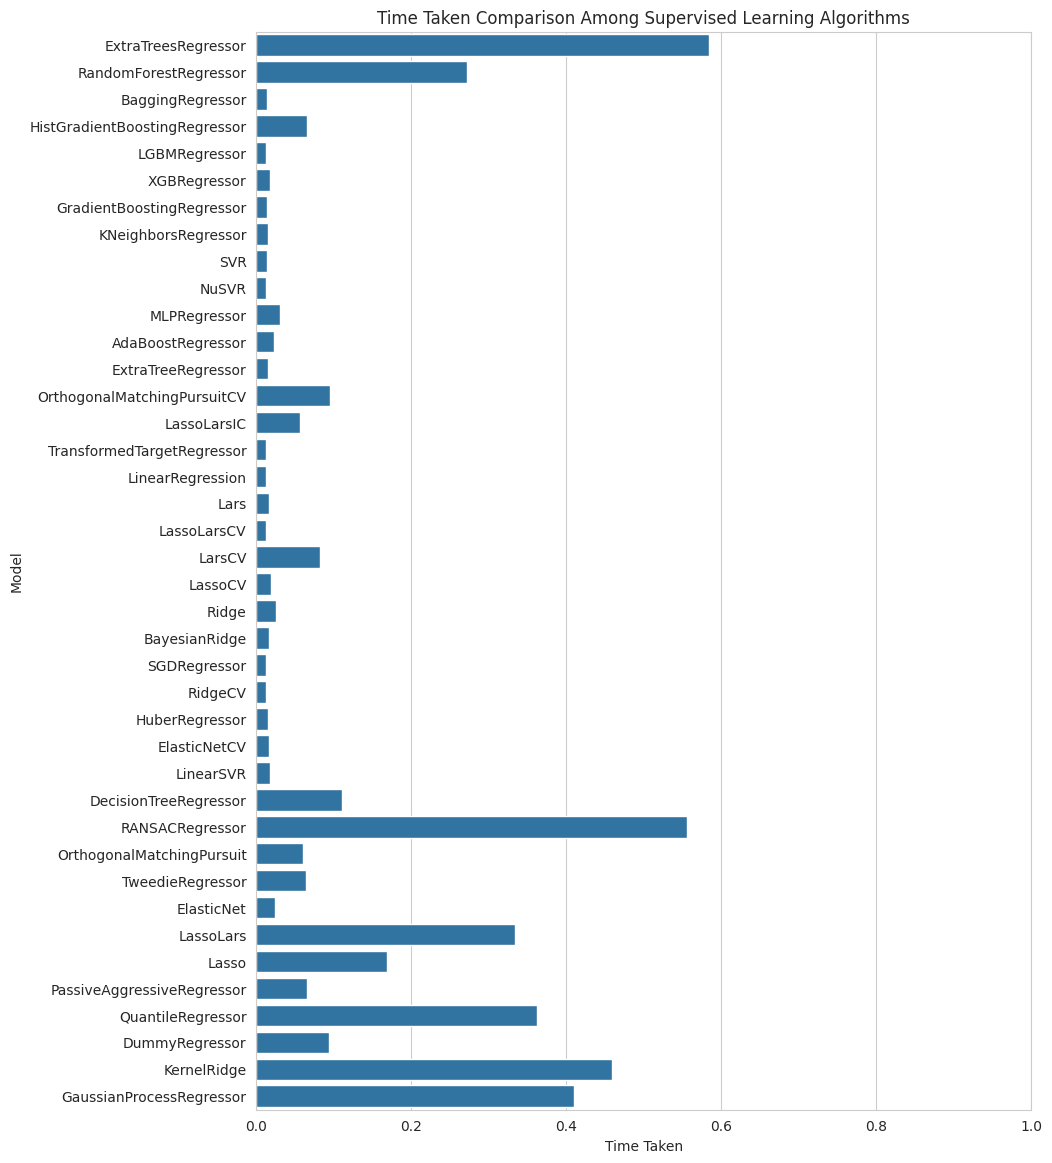

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(10,14))
ax = sns.barplot(y=models.index, x="Time Taken", data=models.sort_values("RMSE", ascending=False))
ax.set(xlim=(0,1))
ax.set_xlabel('Time Taken')
ax.set_title('Time Taken Comparison Among Supervised Learning Algorithms')
plt